In [1]:
from pathlib import Path
import re
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import re
from collections import Counter

DATA_DIR = Path("/home/arabella/Desktop/dehumanisation-analysis-wefe/data/raw/sz_txt")
MAX_FILES = None  # <- test with only first 20 files (set None for all)

STOPWORDS = {
    "der", "die", "das", "ein", "eine", "einer", "eines", "einem", "einen","was","sagt","sei", "soll","muss",
    "und", "oder", "aber", "wenn", "dann", "denn", "dem","für", "mit", "ohne", "gegen", "über", "unter", "zwischen", "hat",
    "zu", "zum", "zur", "von", "vom", "im", "in", "am", "an", "auf", "aus", "bei", "mit", "nach", "vor", "über", "unter",
    "ist", "sind", "war", "waren", "sein", "wird", "werden", "wurde", "wurden","gibt","hier",
    "ich", "du", "er", "sie", "es", "wir", "ihr", "man","den","als","sich","des", "viele","jetzt",
    "mich", "dich", "ihn", "uns", "euch", "seit","nun","haben","will","dort","kann","alle", "können",
    "mein", "meine", "dein", "deine", "sein", "seine", "ihr", "ihre","haben","zwei","durch","immer","wieder",
    "nicht", "kein", "keine", "ja", "nein", "hatte","seiner","doch", "bis","weil","sagte",
    "auch", "noch", "nur", "schon", "sehr", "mehr", "weniger", "so", "wie","habe",
    "dass", "daß", "dies", "diese", "dieser", "dieses", "jener", "jene", "jenes"
}

def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zäöüß\s]", " ", text)
    words = text.split()
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

def main():
    all_words = []
    files = sorted(DATA_DIR.glob("*.txt"))
    if MAX_FILES is not None:
        files = files[:MAX_FILES]

    for txt_file in files:
        text = txt_file.read_text(encoding="utf-8", errors="ignore")
        all_words.extend(tokenize(text))

    counts = Counter(all_words)

    print(f"Processed files: {len(files)}")
    print(f"Total words (after cleaning): {len(all_words)}")
    print("\nTop 30 words:")
    for word, n in counts.most_common(30):
        print(f"{word}: {n}")

if __name__ == "__main__":
    main()

Processed files: 2522
Total words (after cleaning): 1181489

Top 30 words:
israel: 11376
hamas: 8630
gaza: 6503
menschen: 4578
krieg: 4559
israels: 3277
israelischen: 3250
gazastreifen: 3041
politik: 2859
oktober: 2693
deutschland: 2637
netanjahu: 2566
israelische: 2549
leben: 2160
selbst: 2112
land: 2045
palästinenser: 2035
usa: 1999
biden: 1955
geiseln: 1950
regierung: 1936
welt: 1833
geht: 1824
worden: 1813
damit: 1811
etwa: 1720
armee: 1719
diesem: 1701
mal: 1691
ihren: 1690


Processed files: 2522
Total words (after cleaning): 1181489


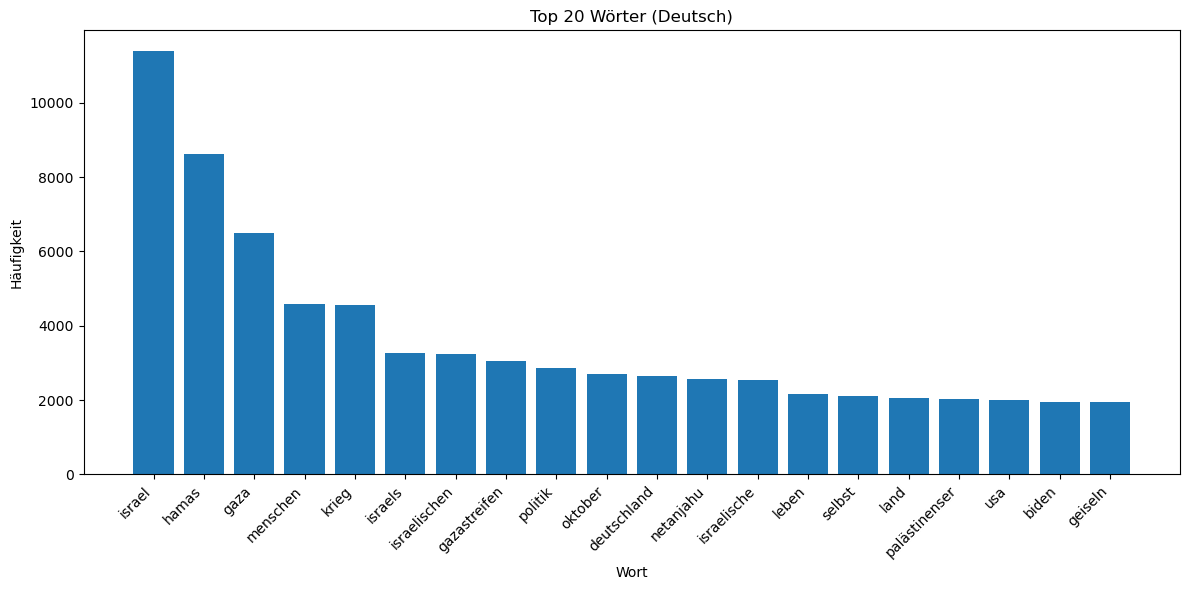

In [3]:

def main():
    all_words = []
    files = sorted(DATA_DIR.glob("*.txt"))
    if MAX_FILES is not None:
        files = files[:MAX_FILES]

    for txt_file in files:
        text = txt_file.read_text(encoding="utf-8", errors="ignore")
        all_words.extend(tokenize(text))

    counts = Counter(all_words)

    print(f"Processed files: {len(files)}")
    print(f"Total words (after cleaning): {len(all_words)}")

    top_n = 20
    most_common = counts.most_common(top_n)
    words = [w for w, _ in most_common]
    freqs = [f for _, f in most_common]

    plt.figure(figsize=(12, 6))
    plt.bar(words, freqs)
    plt.title(f"Top {top_n} Wörter (Deutsch)")
    plt.xlabel("Wort")
    plt.ylabel("Häufigkeit")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [4]:
from pathlib import Path
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# CONFIG
# =========================
#DATA_DIR = Path("articles")
MAX_FILES = None          # e.g. 300 for testing, None for all
MIN_WORD_LEN = 3
SMOOTHING_WINDOW_DAYS = 7  # rolling average for plots

KEYWORDS = [
    "Geisel", "Freiheit", "Schlachtruf", "Dörfer", "Opfer", "Schuld", "Parole", "Städte",
    "Zivilisten", "Vergebung", "Menschliches Schutzschild", "Gaza", "Kinder", "Sieg",
    "Machtmissbrauch", "Gazastreifen", "Minderjährige", "Selbstverteidigung",
    "Vergeltungsschlag", "Israel", "Jugendliche", "Demokratie", "Handlungsspielraum",
    "Exil", "Junge", "Toleranz", "Barbarei", "Diaspora", "Mädchen", "Schuld",
    "Propaganda", "Infrastruktur", "Baby", "Schmerz", "Verbrechen Menschlichkeit",
    "Grenzübergang", "Säugling", "Solidarität", "Kontroverse", "Umstrittene Gebiete",
    "Gefangene", "Legitimität", "Terrorsymbol", "Palästinenserstaat", "Frauen",
    "Rechtfertigung", "Bestialität", "Tunnel", "Männer", "Sicherheit", "Kälte",
    "Tunnelnetz", "Alte", "Gerechtigkeit", "Korruption", "sichere Zone", "Juden",
    "Schutz", "Protest", "Schutzbunker", "Muslime", "Vergeltung", "Straßenprotest",
    "Territorium", "Palästinenser", "Hass", "Demonstration", "Kriegszone", "Israelis",
    "Rache", "Recht", "Kriegsgebiet", "Menschen", "Lust", "Gesetz", "Naher Osten",
    "Bürger", "Gelüste", "Existenzrecht", "Mittlerer Osten", "Einwohner", "Zuflucht",
    "Verbot", "Gefängnis", "Bewohner", "Überleben", "Hassworte", "Käfig", "Diaspora",
    "Widerstand", "Gewalttaten", "Tunnel", "Wohnhäuser", "Exil", "Versammlung",
    "Kommandozentrale", "Christen", "Trauer", "Kundgebung", "Arabischer Staat",
    "Homosexuelle", "Schrecken", "Versammlungsrecht", "Besetztes Gebiet", "Araber",
    "Gedenken", "Hetzparolen", "Massengrab", "Krankenhaus", "AusnahmesituationKindermörder",
    "Schlachtfeld", "Journalist", "Not", "Hilfe", "Schutzraum", "Klinik", "Notsituation",
    "Hilfslieferung", "Schutzzone", "Patienten", "Leid", "Blockade", "Krisengebiet",
    "Ärzte", "Koexoistence", "Sanktion", "Krankenhaus", "Sanitäter", "Bedrohung",
    "Abriegelung", "Vorort", "Leichen", "Frieden", "Bombardement", "Gaza-Stadt",
    "Leichenberge", "Deeskalation", "Rakete", "Ziele", "Töchter", "Versöhnung", "Bombe",
    "urbanes Gelände", "Söhne", "Rettung", "Bombardierung", "Front", "Väter", "Kontext",
    "Völerrecht", "Westjordanland", "Mütter", "Stellvertreterkrieg", "Hilfsgüter",
    "Region", "Großmütter", "Rebellion", "Unterstützung", "Schule", "Enkel",
    "Freiheitskampf", "Zwei-Staaten-Lösung", "Kindergärten", "Personen", "Kolonialismus",
    "Flugabwehr", "geschützte Plätze", "Staatsbürger", "Apartheid", "Bombenhagel",
    "Häuserblock", "Familien", "Wasser", "Entlassung", "geschützter Korridor",
    "Mitbürger", "Brot", "Gewaltspirale", "Fluchtkorridor", "palästinensisches Volk",
    "Hunger", "Kritik", "Fläche", "Bevölkerung", "Feuerpause", "Nahostkonflikt",
    "Flüchtlingslager", "Arbeitskräfte", "Kollektivbestrafung", "Vermisste",
    "UN-Resolution", "Geflüchtete", "Todesstrafe", "Flüchtlinge", "Gefangenenaustausch",
    "Entführte", "Fake News",
]

# =========================
# HELPERS
# =========================
def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zäöüß\s\-]", " ", text)
    words = text.split()
    return [w for w in words if w not in STOPWORDS and len(w) >= MIN_WORD_LEN]

def parse_date_and_category_from_first_line(text: str):
    first_line = text.splitlines()[0].strip() if text.splitlines() else ""
    # Matches date at start, e.g. "03.10.2024 MEINUNG"
    m = re.match(r"^\s*(\d{2}\.\d{2}\.\d{4})\s*(.*)$", first_line)
    if not m:
        return pd.NaT, ""

    date_str = m.group(1)
    category = m.group(2).strip()  # may be empty
    dt = pd.to_datetime(date_str, format="%d.%m.%Y", errors="coerce")
    return dt, category

def count_keywords(tokens, keywords):
    token_counter = Counter(tokens)
    joined = " ".join(tokens)
    out = {}
    for kw in keywords:
        k = kw.lower().strip()
        if not k:
            continue
        if " " in k:
            pattern = r"(?<!\S)" + re.escape(k) + r"(?!\S)"
            out[k] = len(re.findall(pattern, joined))
        else:
            out[k] = token_counter.get(k, 0)
    return out
def smooth_timeseries(df, date_col, value_col, freq="W", roll_window=4, mode="sum"):
    s = (
        df[[date_col, value_col]]
        .dropna()
        .set_index(date_col)[value_col]
        .resample(freq)
    )
    s = s.sum() if mode == "sum" else s.mean()
    s_smooth = s.rolling(roll_window, min_periods=1).mean()
    return s, s_smooth
# =========================
# MAIN
# =========================
def main():
    files = sorted(DATA_DIR.glob("*.txt"))
    if MAX_FILES is not None:
        files = files[:MAX_FILES]

    print(f"Loaded files: {len(files)}")

    records = []
    bad_date_files = []

    for fp in files:
        text = fp.read_text(encoding="utf-8", errors="ignore")
        dt, category = parse_date_and_category_from_first_line(text)

        if pd.isna(dt):
            bad_date_files.append(fp.name)
            continue

        # remove first line (date + category) from analysis text
        lines = text.splitlines()
        body = "\n".join(lines[1:]) if len(lines) > 1 else ""
        tokens = tokenize(body)

        kw_counts = count_keywords(tokens, KEYWORDS)

        rec = {
            "file": fp.name,
            "date": dt.normalize(),
            "category": category.strip(),
            "token_count": len(tokens),
        }
        rec.update(kw_counts)
        records.append(rec)

    if not records:
        print("No valid records found. Check first-line format (expected: 'dd.mm.yyyy CATEGORY').")
        return

    df = pd.DataFrame(records).sort_values("date")
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["category"] = df["category"].astype(str).str.strip()

    # Save article-level data
    df.to_csv("article_level_time_data.csv", index=False, encoding="utf-8")
    print(f"Valid articles: {len(df)}")
    print(f"Files with invalid/missing date: {len(bad_date_files)}")
    if bad_date_files:
        pd.Series(bad_date_files).to_csv(
            "files_with_bad_date.csv", index=False, header=["file"], encoding="utf-8"
        )
        print("Saved files_with_bad_date.csv")

    # keyword columns only (exclude metadata)
    keyword_cols = [
        c for c in df.columns
        if c not in {"file", "date", "category", "token_count"}
    ]

    # force numeric for safety
    for c in keyword_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

    # -------------------------
    # A) Daily overall trends
    # -------------------------
    agg_daily = {"token_count": "sum"}
    agg_daily.update({k: "sum" for k in keyword_cols})

    daily = (
        df.groupby("date", as_index=False)
          .agg(agg_daily)
          .sort_values("date")
    )

    for k in keyword_cols:
        daily[f"{k}_per_1000"] = (daily[k] / daily["token_count"]) * 1000

    daily_article_counts = df.groupby("date").size().rename("article_count").reset_index()
    daily = daily.merge(daily_article_counts, on="date", how="left")
    daily.to_csv("daily_keyword_trends.csv", index=False, encoding="utf-8")
    print("Saved daily_keyword_trends.csv")

    # -------------------------
    # B) Daily trends by category
    # -------------------------
    agg_cat = {"token_count": "sum"}
    agg_cat.update({k: "sum" for k in keyword_cols})

    daily_cat = (
        df.groupby(["date", "category"], as_index=False)
          .agg(agg_cat)
          .sort_values(["date", "category"])
    )

    for k in keyword_cols:
        daily_cat[f"{k}_per_1000"] = (daily_cat[k] / daily_cat["token_count"]) * 1000

    daily_cat_article_counts = (
        df.groupby(["date", "category"]).size().rename("article_count").reset_index()
    )
    daily_cat = daily_cat.merge(
        daily_cat_article_counts, on=["date", "category"], how="left"
    )
    daily_cat.to_csv("daily_keyword_trends_by_category.csv", index=False, encoding="utf-8")
    print("Saved daily_keyword_trends_by_category.csv")

    # -------------------------
    # C) Monthly overall trends
    # -------------------------
    monthly = daily.copy()
    monthly["month"] = monthly["date"].dt.to_period("M").dt.to_timestamp()

    monthly = (
        monthly.groupby("month", as_index=False)
               .agg({"token_count": "sum", "article_count": "sum", **{k: "sum" for k in keyword_cols}})
    )

    for k in keyword_cols:
        monthly[f"{k}_per_1000"] = (monthly[k] / monthly["token_count"]) * 1000

    monthly.to_csv("monthly_keyword_trends.csv", index=False, encoding="utf-8")
    print("Saved monthly_keyword_trends.csv")

        # -------------------------
    # D) Smoothed Plots
    # -------------------------
    # 1) Articles over time (weekly + rolling mean)
    raw_articles, smooth_articles = smooth_timeseries(
        daily, "date", "article_count", freq="W", roll_window=4, mode="sum"
    )

    plt.figure(figsize=(12, 5))
    plt.plot(raw_articles.index, raw_articles.values, alpha=0.30, linewidth=1.2, label="Roh (wöchentlich)")
    plt.plot(smooth_articles.index, smooth_articles.values, linewidth=2.5, label="Geglättet (4-Wochen-MA)")
    plt.title("Artikel über die Zeit (wöchentlich, geglättet)")
    plt.xlabel("Datum")
    plt.ylabel("Artikelanzahl")
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("time_articles_per_week_smoothed.png", dpi=200)
    plt.show()

    # 2) Top keyword trends (per-1000), weekly mean + rolling mean
    total_counts = {k: daily[k].sum() for k in keyword_cols}
    top_keywords = sorted(total_counts, key=total_counts.get, reverse=True)[:8]

    plt.figure(figsize=(13, 6))
    for k in top_keywords:
        col = f"{k}_per_1000"
        raw_k, smooth_k = smooth_timeseries(
            daily, "date", col, freq="W", roll_window=4, mode="mean"
        )
        plt.plot(smooth_k.index, smooth_k.values, linewidth=2, label=k)

    plt.title("Top-Keyword-Trends pro 1.000 Wörter (wöchentlich, 4-Wochen-MA)")
    plt.xlabel("Datum")
    plt.ylabel("Häufigkeit pro 1.000 Wörter")
    plt.legend(loc="upper right", ncol=2, fontsize=9)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("time_top_keywords_trend_smoothed.png", dpi=200)
    plt.show()

    print("Saved plots: time_articles_per_week_smoothed.png, time_top_keywords_trend_smoothed.png")

Loaded files: 2522
Valid articles: 2522
Files with invalid/missing date: 0


/tmp/ipykernel_29221/135767460.py:172: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .agg(agg_daily)
/tmp/ipykernel_29221/135767460.py:177: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily[f"{k}_per_1000"] = (daily[k] / daily["token_count"]) * 1000


Saved daily_keyword_trends.csv


/tmp/ipykernel_29221/135767460.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .agg(agg_cat)
/tmp/ipykernel_29221/135767460.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily_cat[f"{k}_per_1000"] = (daily_cat[k] / daily_cat["token_count"]) * 1000


Saved daily_keyword_trends_by_category.csv
Saved monthly_keyword_trends.csv


/tmp/ipykernel_29221/135767460.py:216: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .agg({"token_count": "sum", "article_count": "sum", **{k: "sum" for k in keyword_cols}})
/tmp/ipykernel_29221/135767460.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  monthly[f"{k}_per_1000"] = (monthly[k] / monthly["token_count"]) * 1000


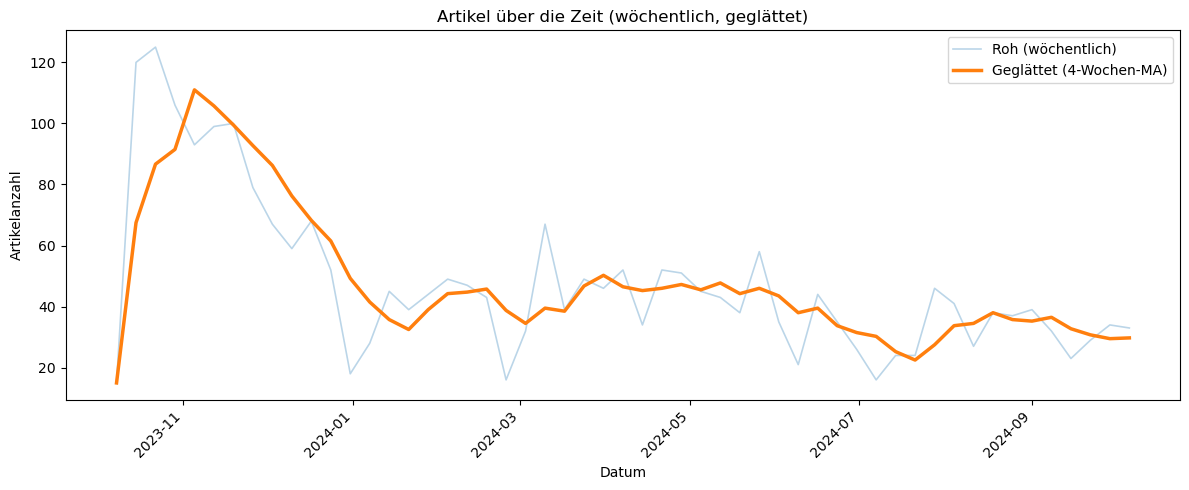

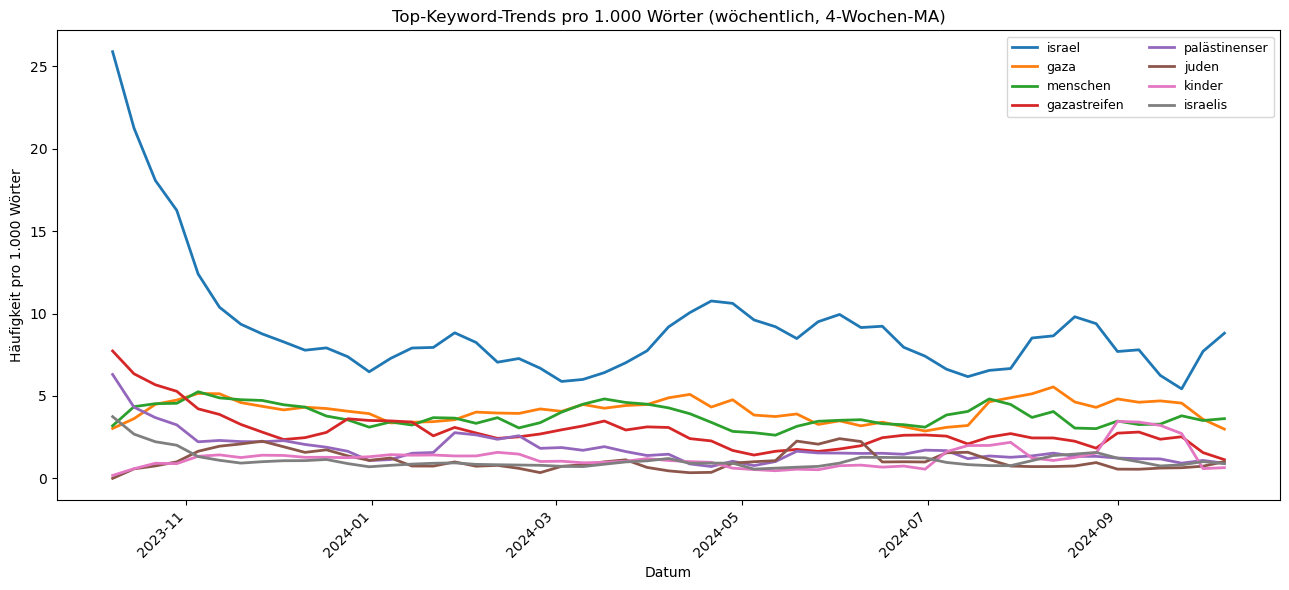

Saved plots: time_articles_per_week_smoothed.png, time_top_keywords_trend_smoothed.png


In [5]:
if __name__ == "__main__":
    main()

/tmp/ipykernel_30885/333684285.py:164: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"frame_{frame}"] = df[present].sum(axis=1) if present else 0.0
/tmp/ipykernel_30885/333684285.py:165: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"frame_{frame}_per_1000"] = (df[f"frame_{frame}"] / df["token_count"]) * 1000
/tmp/ipykernel_30885/333684285.py:164: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

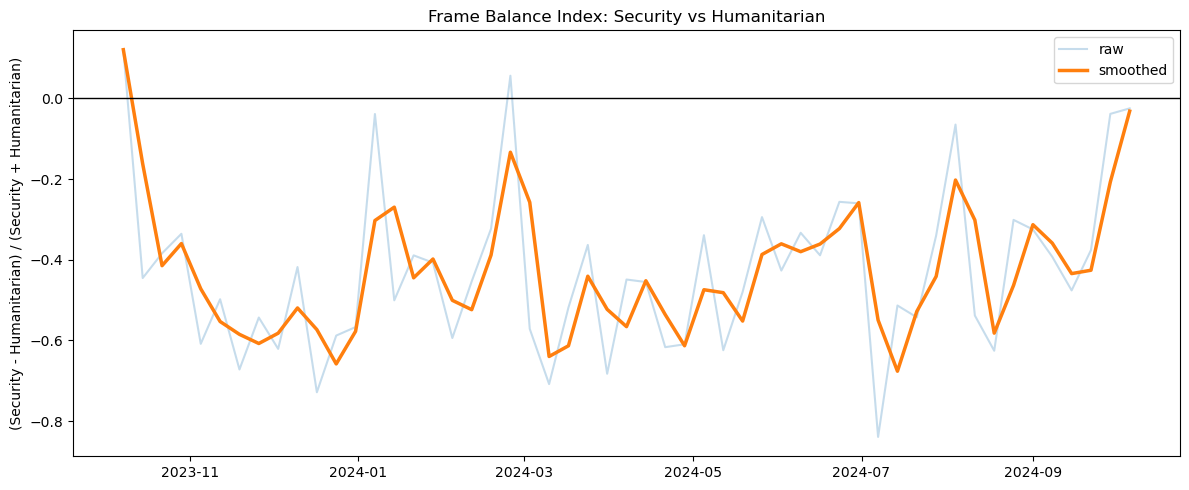

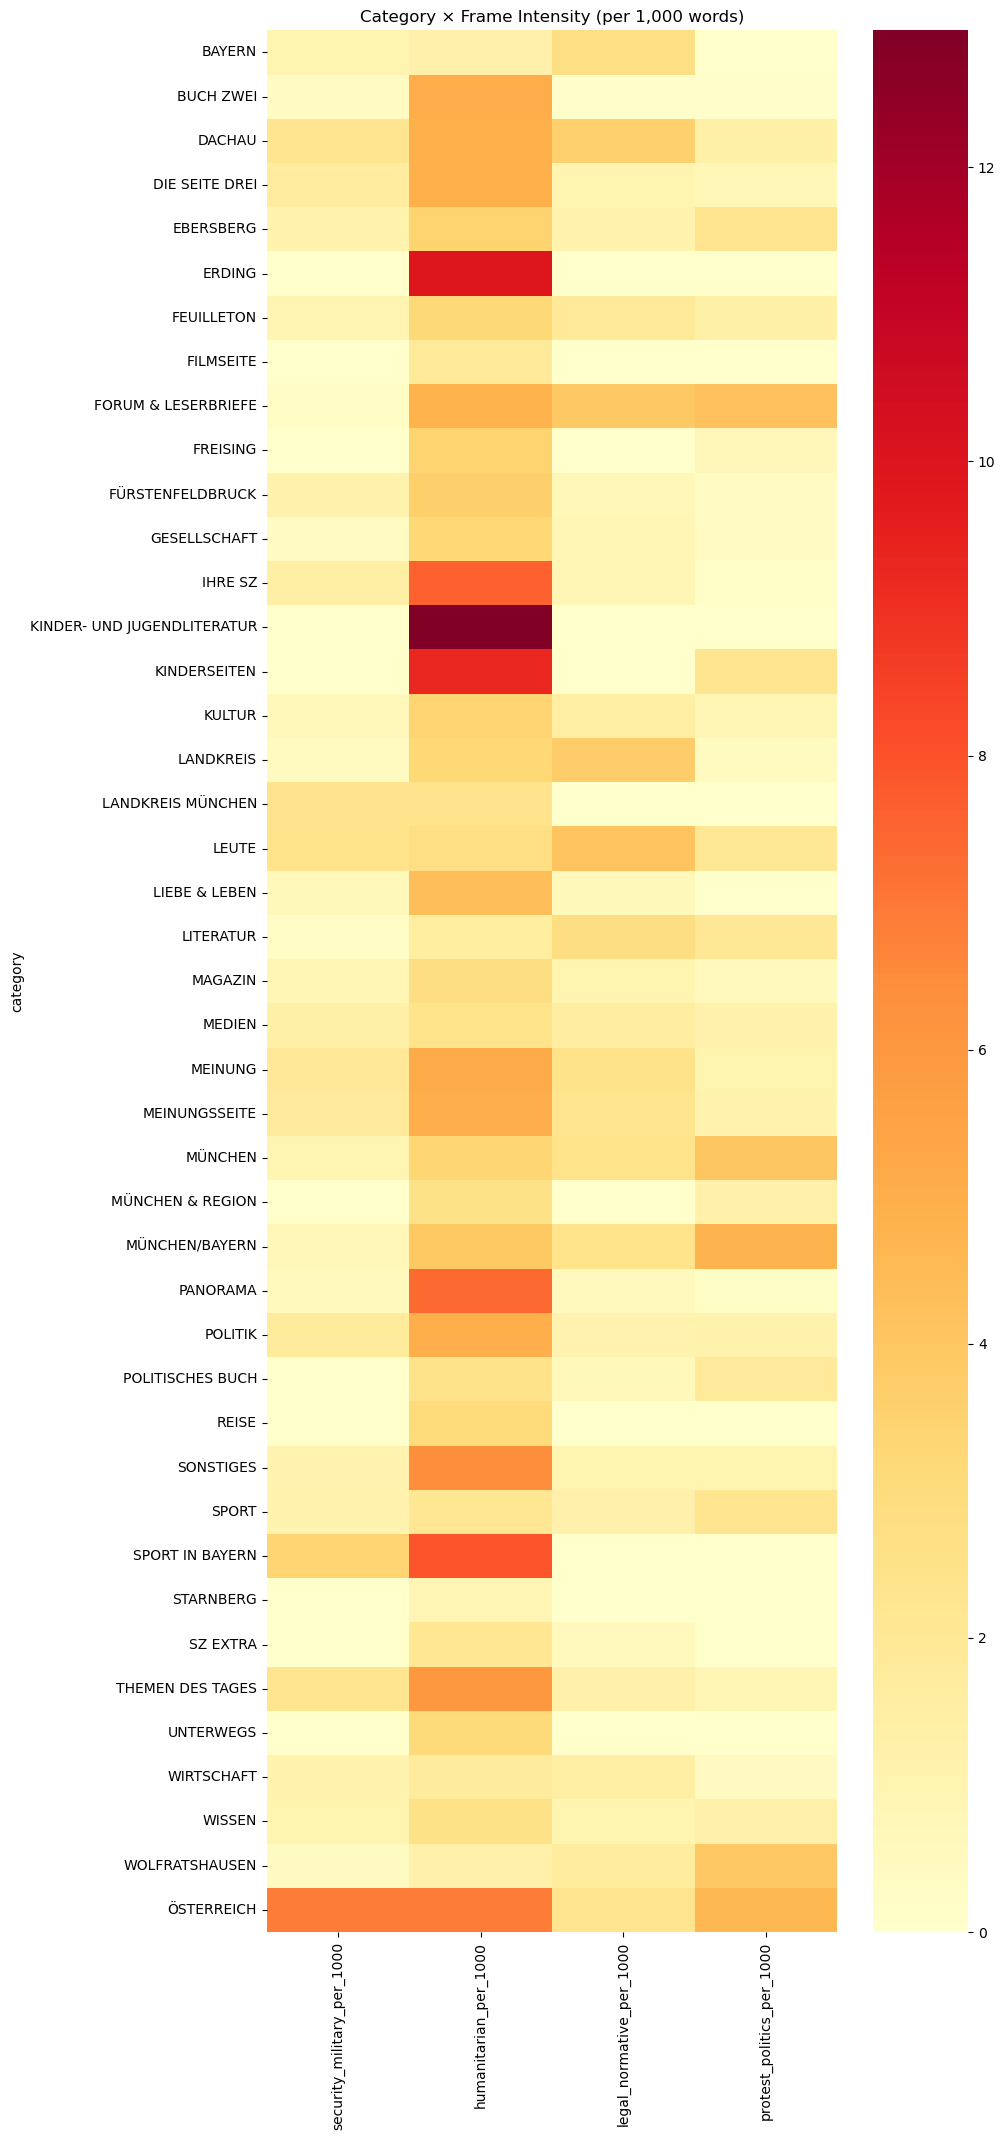

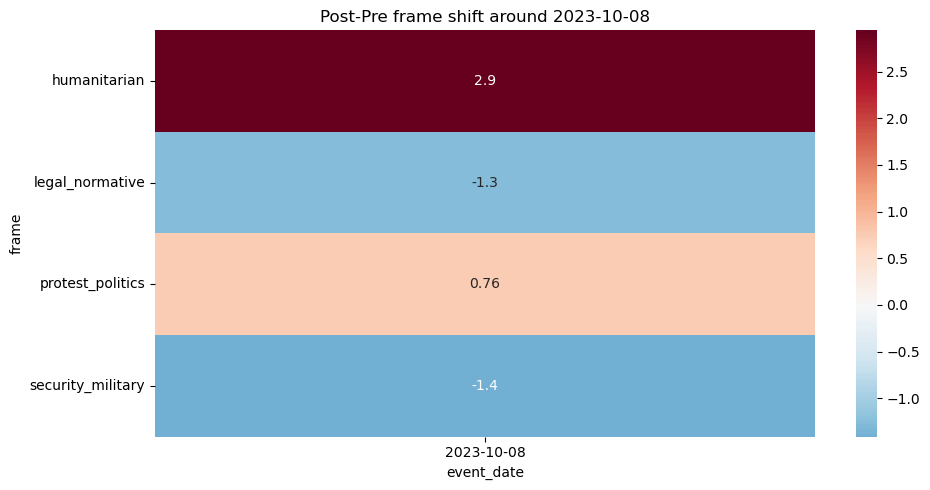

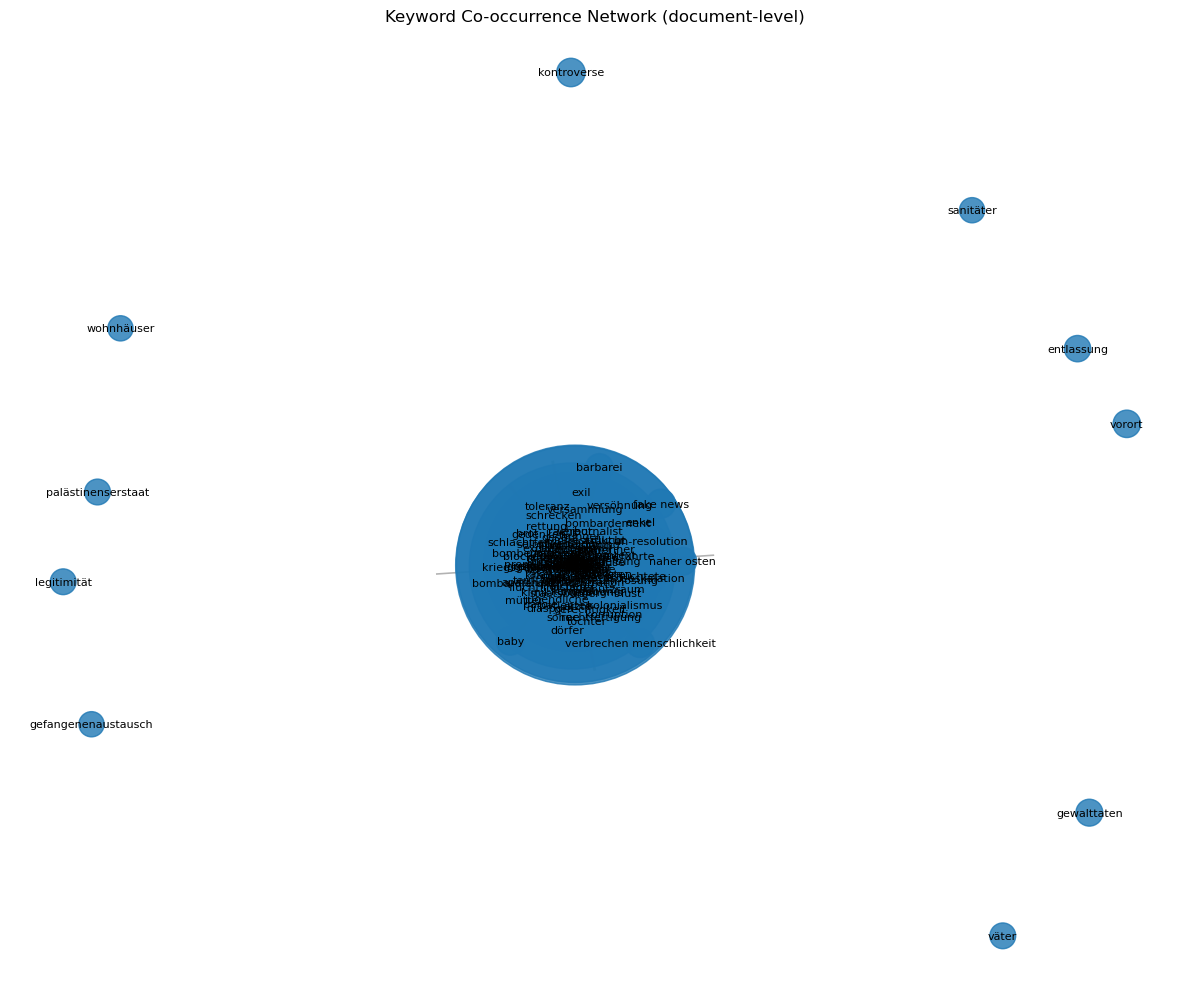

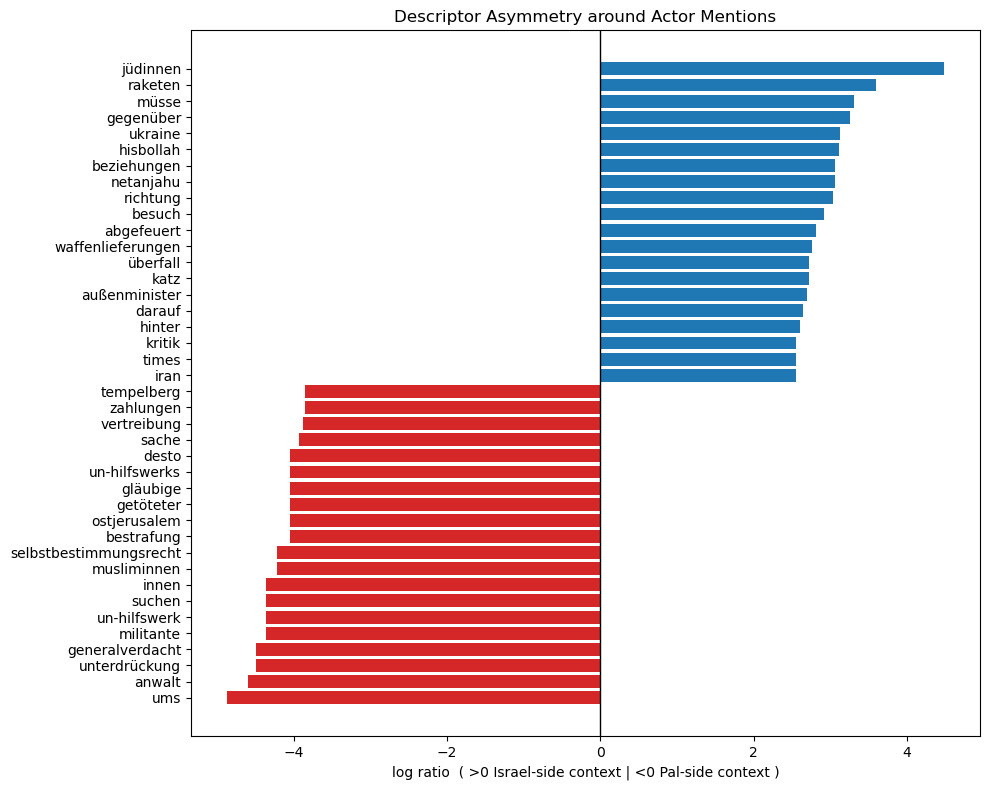

Saved:
- test1_frame_balance_index.png
- test1_frame_daily.csv
- test2_category_frame_heatmap.png
- test2_category_frame.csv
- test3_event_window_pre_post.csv
- test3_event_shift_heatmap.png
- test4_cooccurrence_network.png
- test4_cooccurrence_edges.csv
- test5_descriptor_asymmetry.csv
- test5_descriptor_asymmetry.png


In [6]:
# bias_advanced_tests.py
from pathlib import Path
import re
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# =========================
# CONFIG
# =========================
#DATA_DIR = Path("articles")
MAX_FILES = None
MIN_WORD_LEN = 3
WINDOW = 1                 # context window for descriptor asymmetry
COOC_MIN_EDGE = 25         # min co-occurrence count to draw edge
TOP_DESCRIPTOR_N = 20
FREQ = "W"                 # weekly aggregation for trends
ROLL = 2                   # smoothing window (weeks)

EVENT_DATES = [
    "2023-10-08",
    "2024-01-24",
    "2024-10-01",
]


# --- your keywords (deduplicated + lowercase during processing)
KEYWORDS = [
    "Geisel","Freiheit","Schlachtruf","Dörfer","Opfer","Schuld","Parole","Städte","Zivilisten","Vergebung",
    "Menschliches Schutzschild","Gaza","Kinder","Sieg","Machtmissbrauch","Gazastreifen","Minderjährige",
    "Selbstverteidigung","Vergeltungsschlag","Israel","Jugendliche","Demokratie","Handlungsspielraum","Exil",
    "Junge","Toleranz","Barbarei","Diaspora","Mädchen","Propaganda","Infrastruktur","Baby","Schmerz",
    "Verbrechen Menschlichkeit","Grenzübergang","Säugling","Solidarität","Kontroverse","Umstrittene Gebiete",
    "Gefangene","Legitimität","Terrorsymbol","Palästinenserstaat","Frauen","Rechtfertigung","Bestialität",
    "Tunnel","Männer","Sicherheit","Kälte","Tunnelnetz","Alte","Gerechtigkeit","Korruption","sichere Zone",
    "Juden","Schutz","Protest","Schutzbunker","Muslime","Vergeltung","Straßenprotest","Territorium",
    "Palästinenser","Hass","Demonstration","Kriegszone","Israelis","Rache","Recht","Kriegsgebiet","Menschen",
    "Lust","Gesetz","Naher Osten","Bürger","Gelüste","Existenzrecht","Mittlerer Osten","Einwohner","Zuflucht",
    "Verbot","Gefängnis","Bewohner","Überleben","Hassworte","Käfig","Widerstand","Gewalttaten","Wohnhäuser",
    "Versammlung","Kommandozentrale","Christen","Trauer","Kundgebung","Arabischer Staat","Homosexuelle",
    "Schrecken","Versammlungsrecht","Besetztes Gebiet","Araber","Gedenken","Hetzparolen","Massengrab",
    "Krankenhaus","AusnahmesituationKindermörder","Schlachtfeld","Journalist","Not","Hilfe","Schutzraum",
    "Klinik","Notsituation","Hilfslieferung","Schutzzone","Patienten","Leid","Blockade","Krisengebiet","Ärzte",
    "Koexoistence","Sanktion","Sanitäter","Bedrohung","Abriegelung","Vorort","Leichen","Frieden","Bombardement",
    "Gaza-Stadt","Leichenberge","Deeskalation","Rakete","Ziele","Töchter","Versöhnung","Bombe","urbanes Gelände",
    "Söhne","Rettung","Bombardierung","Front","Väter","Kontext","Völerrecht","Westjordanland","Mütter",
    "Stellvertreterkrieg","Hilfsgüter","Region","Großmütter","Rebellion","Unterstützung","Schule","Enkel",
    "Freiheitskampf","Zwei-Staaten-Lösung","Kindergärten","Personen","Kolonialismus","Flugabwehr","geschützte Plätze",
    "Staatsbürger","Apartheid","Bombenhagel","Häuserblock","Familien","Wasser","Entlassung","geschützter Korridor",
    "Mitbürger","Brot","Gewaltspirale","Fluchtkorridor","palästinensisches Volk","Hunger","Kritik","Fläche",
    "Bevölkerung","Feuerpause","Nahostkonflikt","Flüchtlingslager","Arbeitskräfte","Kollektivbestrafung","Vermisste",
    "UN-Resolution","Geflüchtete","Todesstrafe","Flüchtlinge","Gefangenenaustausch","Entführte","Fake News"
]

# Frame dictionaries (edit as you like)
FRAMES = {
    "security_military": [
        "sicherheit","selbstverteidigung","rakete","bombe","bombardement","bombardierung",
        "tunnel","tunnelnetz","kommandozentrale","kriegsgebiet","kriegszone","schlachtfeld","front"
    ],
    "humanitarian": [
        "zivilisten","kinder","leid","hilfe","hilfsgüter","hilfslieferung","flüchtlinge","geflüchtete",
        "krankenhaus","klinik","patienten","schutzraum","schutzzone","überleben","hunger","wasser"
    ],
    "legal_normative": [
        "recht","gesetz","legitimität","un-resolution","existenzrecht","völerrecht","gerechtigkeit","demokratie"
    ],
    "protest_politics": [
        "protest","demonstration","kundgebung","versammlungsrecht","kritik","kontroverse","korruption","apartheid"
    ],
}

ACTOR_GROUPS = {
    "israel_side": ["israel", "israelis", "juden","israeli"],
    "pal_side": ["palästinenser", "palästinensisches volk", "palästinenserstaat", "araber", "muslime"],
}

# =========================
# HELPERS
# =========================
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zäöüß\s\-]", " ", text)
    words = text.split()
    return [w for w in words if len(w) >= MIN_WORD_LEN and w not in STOPWORDS]

def parse_date_category(first_line):
    m = re.match(r"^\s*(\d{2}\.\d{2}\.\d{4})\s*(.*)$", first_line.strip())
    if not m:
        return pd.NaT, ""
    dt = pd.to_datetime(m.group(1), format="%d.%m.%Y", errors="coerce")
    cat = m.group(2).strip()
    return dt, cat

def count_terms(tokens, terms):
    c = Counter(tokens)
    joined = " ".join(tokens)
    out = {}
    for t in terms:
        k = t.lower().strip()
        if " " in k:
            out[k] = len(re.findall(r"(?<!\S)" + re.escape(k) + r"(?!\S)", joined))
        else:
            out[k] = c.get(k, 0)
    return out

def smooth_series(s, roll=4):
    return s.rolling(roll, min_periods=1).mean()

# =========================
# LOAD DATA
# =========================
files = sorted(DATA_DIR.glob("*.txt"))
if MAX_FILES is not None:
    files = files[:MAX_FILES]

records = []
doc_tokens = {}  # for co-occurrence + descriptor tests

keywords_clean = sorted(set([k.lower().strip() for k in KEYWORDS if k.strip()]))

for fp in files:
    txt = fp.read_text(encoding="utf-8", errors="ignore")
    lines = txt.splitlines()
    first = lines[0] if lines else ""
    dt, cat = parse_date_category(first)
    if pd.isna(dt):
        continue

    body = "\n".join(lines[1:]) if len(lines) > 1 else ""
    tokens = tokenize(body)
    doc_tokens[fp.name] = tokens

    kw = count_terms(tokens, keywords_clean)

    rec = {
        "file": fp.name,
        "date": dt.normalize(),
        "category": cat,
        "token_count": len(tokens),
    }
    rec.update(kw)
    records.append(rec)

df = pd.DataFrame(records).sort_values("date")
if df.empty:
    raise ValueError("No valid articles parsed.")

for c in df.columns:
    if c not in {"file","date","category"}:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

keyword_cols = [c for c in df.columns if c not in {"file","date","category","token_count"}]

# =========================
# TEST 1: Frame Balance Index over time
# =========================
for frame, terms in FRAMES.items():
    terms = [t.lower() for t in terms]
    present = [t for t in terms if t in df.columns]
    df[f"frame_{frame}"] = df[present].sum(axis=1) if present else 0.0
    df[f"frame_{frame}_per_1000"] = (df[f"frame_{frame}"] / df["token_count"]) * 1000

daily = df.groupby("date", as_index=False).agg(
    {"token_count":"sum", **{f"frame_{f}":"sum" for f in FRAMES}}
).sort_values("date")

for f in FRAMES:
    daily[f"{f}_per_1000"] = (daily[f"frame_{f}"] / daily["token_count"]) * 1000

eps = 1e-9
daily["frame_balance_security_minus_humanitarian"] = (
    (daily["security_military_per_1000"] - daily["humanitarian_per_1000"]) /
    (daily["security_military_per_1000"] + daily["humanitarian_per_1000"] + eps)
)

# plot
s = daily.set_index("date")["frame_balance_security_minus_humanitarian"].resample(FREQ).mean()
s_sm = smooth_series(s, ROLL)
plt.figure(figsize=(12,5))
plt.plot(s.index, s.values, alpha=0.25, label="raw")
plt.plot(s_sm.index, s_sm.values, linewidth=2.5, label="smoothed")
plt.axhline(0, color="black", linewidth=1)
plt.title("Frame Balance Index: Security vs Humanitarian")
plt.ylabel("(Security - Humanitarian) / (Security + Humanitarian)")
plt.legend()
plt.tight_layout()
plt.savefig("test1_frame_balance_index.png", dpi=220)
plt.show()

# =========================
# TEST 2: Category x Frame heatmap
# =========================
cat_frame = df.groupby("category", as_index=False).agg(
    {"token_count":"sum", **{f"frame_{f}":"sum" for f in FRAMES}}
)
for f in FRAMES:
    cat_frame[f"{f}_per_1000"] = (cat_frame[f"frame_{f}"] / cat_frame["token_count"]) * 1000

heat = cat_frame.set_index("category")[[f"{f}_per_1000" for f in FRAMES]]
plt.figure(figsize=(10, max(4, 0.5*len(heat))))
sns.heatmap(heat, cmap="YlOrRd", annot=False)
plt.title("Category × Frame Intensity (per 1,000 words)")
plt.tight_layout()
plt.savefig("test2_category_frame_heatmap.png", dpi=220)
plt.show()

# =========================
# TEST 3: Event-window pre/post comparison
# =========================
event_rows = []
for ev in EVENT_DATES:
    ev_dt = pd.to_datetime(ev)
    pre = df[df["date"] < ev_dt]
    post = df[df["date"] >= ev_dt]

    for f in FRAMES:
        pre_rate = (pre[f"frame_{f}"].sum() / pre["token_count"].sum() * 1000) if pre["token_count"].sum() > 0 else np.nan
        post_rate = (post[f"frame_{f}"].sum() / post["token_count"].sum() * 1000) if post["token_count"].sum() > 0 else np.nan
        event_rows.append({
            "event_date": ev,
            "frame": f,
            "pre_per_1000": pre_rate,
            "post_per_1000": post_rate,
            "delta_post_minus_pre": post_rate - pre_rate if pd.notna(pre_rate) and pd.notna(post_rate) else np.nan
        })

event_df = pd.DataFrame(event_rows)
event_df.to_csv("test3_event_window_pre_post.csv", index=False, encoding="utf-8")

# quick plot
plt.figure(figsize=(10,5))
pivot = event_df[event_df["event_date"] == EVENT_DATES[0]].pivot(index="frame", columns="event_date", values="delta_post_minus_pre")
sns.heatmap(pivot, annot=True, cmap="RdBu_r", center=0)
plt.title(f"Post-Pre frame shift around {EVENT_DATES[0]}")
plt.tight_layout()
plt.savefig("test3_event_shift_heatmap.png", dpi=220)
plt.show()

# =========================
# TEST 4: Co-occurrence network of keywords (doc-level)
# =========================
kw_set = set(keyword_cols)
pair_counts = Counter()
node_counts = Counter()

for fname, toks in doc_tokens.items():
    joined = " ".join(toks)
    present = set()
    for k in kw_set:
        if " " in k:
            if re.search(r"(?<!\S)" + re.escape(k) + r"(?!\S)", joined):
                present.add(k)
        else:
            if k in toks:
                present.add(k)
    for k in present:
        node_counts[k] += 1
    present = sorted(present)
    for i in range(len(present)):
        for j in range(i+1, len(present)):
            pair_counts[(present[i], present[j])] += 1

G = nx.Graph()
for k, cnt in node_counts.items():
    if cnt >= 20:
        G.add_node(k, weight=cnt)

for (a,b), w in pair_counts.items():
    if w >= COOC_MIN_EDGE and a in G.nodes and b in G.nodes:
        G.add_edge(a,b,weight=w)

plt.figure(figsize=(12,10))
if len(G.nodes) > 0:
    pos = nx.spring_layout(G, k=0.35, seed=42)
    node_sizes = [G.nodes[n]["weight"]*15 for n in G.nodes]
    edge_widths = [G[u][v]["weight"]/8 for u,v in G.edges]
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title("Keyword Co-occurrence Network (document-level)")
    plt.axis("off")
else:
    plt.text(0.5,0.5,"No edges with current thresholds",ha="center")
plt.tight_layout()
plt.savefig("test4_cooccurrence_network.png", dpi=220)
plt.show()

# save edge list
edges = [{"source":u, "target":v, "weight":d["weight"]} for u,v,d in G.edges(data=True)]
pd.DataFrame(edges).to_csv("test4_cooccurrence_edges.csv", index=False, encoding="utf-8")

# =========================
# TEST 5: Descriptor asymmetry by actor (±WINDOW)
# =========================
actor_terms = {k:[t.lower() for t in v] for k,v in ACTOR_GROUPS.items()}
desc_counts = {k: Counter() for k in actor_terms}

for toks in doc_tokens.values():
    n = len(toks)
    for i, tok in enumerate(toks):
        for grp, terms in actor_terms.items():
            if tok in terms:
                l = max(0, i-WINDOW)
                r = min(n, i+WINDOW+1)
                ctx = toks[l:i] + toks[i+1:r]
                for w in ctx:
                    if len(w) >= MIN_WORD_LEN and w not in STOPWORDS:
                        desc_counts[grp][w] += 1

# log-odds style asymmetry score
all_words = set(desc_counts["israel_side"].keys()) | set(desc_counts["pal_side"].keys())
rows = []
total_i = sum(desc_counts["israel_side"].values()) + 1
total_p = sum(desc_counts["pal_side"].values()) + 1

for w in all_words:
    ci = desc_counts["israel_side"][w] + 0.5
    cp = desc_counts["pal_side"][w] + 0.5
    rate_i = ci / total_i
    rate_p = cp / total_p
    score = np.log(rate_i / rate_p)  # >0 israel-side context, <0 pal-side context
    rows.append({"word":w, "israel_ctx_count":ci-0.5, "pal_ctx_count":cp-0.5, "log_ratio":score})

desc_df = pd.DataFrame(rows).sort_values("log_ratio", ascending=False)
desc_df.to_csv("test5_descriptor_asymmetry.csv", index=False, encoding="utf-8")

top_pos = desc_df.head(TOP_DESCRIPTOR_N).copy()
top_neg = desc_df.tail(TOP_DESCRIPTOR_N).copy()

plot_df = pd.concat([top_neg, top_pos]).sort_values("log_ratio")
colors = ["#d62728" if x < 0 else "#1f77b4" for x in plot_df["log_ratio"]]

plt.figure(figsize=(10,8))
plt.barh(plot_df["word"], plot_df["log_ratio"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Descriptor Asymmetry around Actor Mentions")
plt.xlabel("log ratio  ( >0 Israel-side context | <0 Pal-side context )")
plt.tight_layout()
plt.savefig("test5_descriptor_asymmetry.png", dpi=220)
plt.show()

# =========================
# OUTPUTS
# =========================
daily.to_csv("test1_frame_daily.csv", index=False, encoding="utf-8")
cat_frame.to_csv("test2_category_frame.csv", index=False, encoding="utf-8")

print("Saved:")
print("- test1_frame_balance_index.png")
print("- test1_frame_daily.csv")
print("- test2_category_frame_heatmap.png")
print("- test2_category_frame.csv")
print("- test3_event_window_pre_post.csv")
print("- test3_event_shift_heatmap.png")
print("- test4_cooccurrence_network.png")
print("- test4_cooccurrence_edges.csv")
print("- test5_descriptor_asymmetry.csv")
print("- test5_descriptor_asymmetry.png")

In [28]:
# Cell 1: config
ATTRIBUTION_CUES = [
    # core
    "laut", "zufolge", "nach angaben", "angaben zufolge", "nach informationen",
    "wie es hieß", "wie verlautete", "demnach", "dem bericht zufolge",

    # reporting verbs (common German news style)
    "sagte", "sagte dazu", "er sagte", "sie sagte", "teilte mit", "mitgeteilt",
    "erklärte", "äußerte", "betonte", "berichtete", "meldete", "verkündete",
    "gab an", "gaben an", "bestätigte", "bestätigten", "dementierte",
    "widersprach", "kündigte an", "räumte ein", "warnte", "so",
    "hieß es", "verlautete", "so der", "so die", "so das",

    # journalistic evidence markers
    "nach berichten", "medienberichten zufolge", "wie die zeitung berichtet",
    "wie die agentur meldet", "nach dpa-informationen", "dpa zufolge",
    "reuters zufolge", "afp zufolge", "ap zufolge",

    # authority/institution attribution anchors
    "nach angaben der regierung", "nach angaben des militärs", "nach angaben der armee",
    "nach angaben der polizei", "nach angaben der behörden", "nach angaben des ministeriums",
    "teilte das ministerium mit", "teilte die armee mit", "teilte die regierung mit",
    "sagte ein sprecher", "sagte eine sprecherin", "so ein sprecher", "so eine sprecherin",

    # uncertainty + attribution combo markers
    "nach eigenen angaben", "nach israelischen angaben", "nach palästinensischen angaben",
    "nach angaben aus", "von offizieller seite", "aus kreisen", "aus sicherheitskreisen"
]
ATTR_WINDOW = 5

In [29]:
# Cell 2: helper
def phrase_in_window(window_tokens, phrase):
    p = phrase.split()
    if len(p) == 1:
        return p[0] in window_tokens
    # phrase match in token window
    for i in range(len(window_tokens) - len(p) + 1):
        if window_tokens[i:i+len(p)] == p:
            return True
    return False

# Replacement Cell 2: substring-based cue matching (better for German phrasing)
def has_attribution_cue(window_tokens, cues):
    window_text = " ".join(window_tokens)
    return any(cue in window_text for cue in cues)

,group,mentions,with_attribution,without_attribution,attribution_rate
0,israel_side,13340,2842,10498,0.213043
1,pal_side,2554,487,2067,0.190681


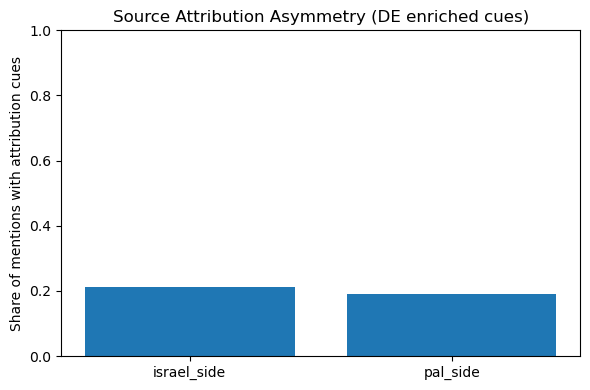

In [30]:
# Replacement Cell 3: rerun attribution asymmetry
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

actor_terms = {k:[t.lower() for t in v] for k,v in ACTOR_GROUPS.items()}
cue_list = [c.lower() for c in ATTRIBUTION_CUES]

counts = {
    grp: Counter({"mentions":0, "with_attribution":0, "without_attribution":0})
    for grp in actor_terms
}

for toks in doc_tokens.values():
    n = len(toks)
    for i, tok in enumerate(toks):
        for grp, terms in actor_terms.items():
            if tok in terms:
                counts[grp]["mentions"] += 1
                l = max(0, i-ATTR_WINDOW)
                r = min(n, i+ATTR_WINDOW+1)
                window = toks[l:r]
                if has_attribution_cue(window, cue_list):
                    counts[grp]["with_attribution"] += 1
                else:
                    counts[grp]["without_attribution"] += 1

rows = []
for grp, c in counts.items():
    m = c["mentions"]
    rate = (c["with_attribution"] / m) if m > 0 else np.nan
    rows.append({
        "group": grp,
        "mentions": m,
        "with_attribution": c["with_attribution"],
        "without_attribution": c["without_attribution"],
        "attribution_rate": rate
    })

attr_df = pd.DataFrame(rows)
display(attr_df)

plt.figure(figsize=(6,4))
plt.bar(attr_df["group"], attr_df["attribution_rate"])
plt.ylim(0, 1)
plt.ylabel("Share of mentions with attribution cues")
plt.title("Source Attribution Asymmetry (DE enriched cues)")
plt.tight_layout()
plt.show()

In [31]:
# Attribution profile by actor side + authority weighting
from collections import defaultdict, Counter
import pandas as pd
import numpy as np

# 1) classify cues by authority level (edit as you like)
HIGH_AUTH = {
    "nach angaben der regierung", "nach angaben des militärs", "nach angaben der armee",
    "nach angaben der polizei", "nach angaben der behörden", "nach angaben des ministeriums",
    "teilte das ministerium mit", "teilte die armee mit", "teilte die regierung mit",
    "dpa zufolge", "reuters zufolge", "afp zufolge", "ap zufolge"
}
MID_AUTH = {
    "nach angaben", "angaben zufolge", "nach informationen", "nach berichten",
    "medienberichten zufolge", "wie die agentur meldet", "wie die zeitung berichtet",
    "bestätigte", "bestätigten", "teilte mit", "erklärte", "berichtete", "meldete"
}
# everything else -> LOW_AUTH

def cue_level(c):
    if c in HIGH_AUTH:
        return "high"
    if c in MID_AUTH:
        return "mid"
    return "low"

level_weight = {"high": 3, "mid": 2, "low": 1}

actor_terms = {k:[t.lower() for t in v] for k,v in ACTOR_GROUPS.items()}
cue_list = [c.lower() for c in ATTRIBUTION_CUES]

# 2) count exact cue hits near actor mentions
cue_counts_by_group = {g: Counter() for g in actor_terms}
mention_counts = Counter()

for toks in doc_tokens.values():
    n = len(toks)
    for i, tok in enumerate(toks):
        for grp, terms in actor_terms.items():
            if tok in terms:
                mention_counts[grp] += 1
                l = max(0, i-ATTR_WINDOW)
                r = min(n, i+ATTR_WINDOW+1)
                wtxt = " ".join(toks[l:r])

                for cue in cue_list:
                    if cue in wtxt:
                        cue_counts_by_group[grp][cue] += 1

# 3) long table
rows = []
for grp, cnt in cue_counts_by_group.items():
    for cue, c in cnt.items():
        lvl = cue_level(cue)
        rows.append({
            "group": grp,
            "cue": cue,
            "count": c,
            "per_100_mentions": (c / mention_counts[grp] * 100) if mention_counts[grp] else np.nan,
            "authority_level": lvl,
            "authority_weight": level_weight[lvl]
        })

cue_df = pd.DataFrame(rows).sort_values(["group","count"], ascending=[True, False])
display(cue_df.head(30))

# 4) group-level authority score
auth_rows = []
for grp in actor_terms:
    sub = cue_df[cue_df["group"] == grp].copy()
    weighted_sum = (sub["count"] * sub["authority_weight"]).sum()
    total_hits = sub["count"].sum()
    avg_auth = (weighted_sum / total_hits) if total_hits > 0 else np.nan
    auth_rows.append({
        "group": grp,
        "mentions": mention_counts[grp],
        "attribution_hits": total_hits,
        "avg_authority_score_1to3": avg_auth
    })

auth_df = pd.DataFrame(auth_rows)
display(auth_df)

# optional saves
cue_df.to_csv("attribution_cue_profile_by_side.csv", index=False, encoding="utf-8")
auth_df.to_csv("attribution_authority_summary_by_side.csv", index=False, encoding="utf-8")

,group,cue,count,per_100_mentions,authority_level,authority_weight
1,israel_side,so,2480,18.590705,low,1
4,israel_side,laut,147,1.101949,low,1
3,israel_side,erklärte,70,0.524738,mid,2
10,israel_side,zufolge,48,0.359820,low,1
6,israel_side,berichtete,28,0.209895,mid,2
9,israel_side,betonte,21,0.157421,low,1
14,israel_side,äußerte,21,0.157421,low,1
13,israel_side,warnte,20,0.149925,low,1
2,israel_side,sagte,17,0.127436,low,1
8,israel_side,meldete,14,0.104948,mid,2


,group,mentions,attribution_hits,avg_authority_score_1to3
0,israel_side,13340,2926,1.043062
1,pal_side,2554,506,1.017787
